In [1]:
import sys, unsio, numpy, agama, scipy.ndimage, scipy.spatial, matplotlib.pyplot as plt


In [13]:
help(unsio.CunsIn)

Help on class CunsIn in module unsio.py_unsio:

class CunsIn(builtins.object)
 |  CunsIn(*args)
 |
 |  Methods defined here:
 |
 |  __init__(self, *args)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  __repr__ = _swig_repr(self) from unsio.py_unsio
 |
 |  close(self)
 |
 |  getArrayF(self, *args)
 |
 |  getArrayI(self, *args)
 |
 |  getFileName(self)
 |
 |  getFileStructure(self)
 |
 |  getInterfaceType(self)
 |
 |  getValueF(self, prop)
 |
 |  getValueI(self, prop)
 |
 |  isValid(self)
 |
 |  nextFrame(self, _bits)
 |
 |  ----------------------------------------------------------------------
 |  Static methods defined here:
 |
 |  __swig_destroy__ = delete_CunsIn(...)
 |
 |  initMap()
 |
 |  ----------------------------------------------------------------------
 |  Data descriptors defined here:
 |
 |  __dict__
 |      dictionary for instance variables
 |
 |  __weakref__
 |      list of weak references to the object
 |
 |  s_mapCompInt
 |
 |  snapshot
 |

In [5]:
times = [1.5, 2.0]
nstars = 1000000
name = '/home/hz420/austreams/Nbody_bar/Vasiliev/fs0.60_fb0.20_Q2.0.out'
snap=unsio.CunsIn(name,"all","all")
name=name.replace('.out','')
while snap.nextFrame(""):
    time=snap.getValueF("time")[1]
    if not any(numpy.isclose(time, times)): continue
    pos =snap.getArrayF("all","pos")[1].reshape(-1,3)
    vel =snap.getArrayF("all","vel")[1].reshape(-1,3)
    mass=snap.getArrayF("all","mass")[1]
    print(time, pos.shape, vel.shape, mass.shape)

        # recenter
    med=numpy.median(pos[:nstars], axis=0)
    use=numpy.sum((pos[:nstars]-med)**2, axis=1) < 4.0**2
    med=numpy.median(pos[:nstars][use], axis=0)
    pos-=med
    # rectify the disk plane - bring it back to z=0
    x,y=numpy.linalg.lstsq(pos[:nstars,0:2], -pos[:nstars,2], rcond=None)[0]
    s=x**2+y**2
    w=(1+s)**0.5
    mat=numpy.array([ [ (x**2/w+y**2)/s, x*y/s*(1/w-1), -x/w ], [ x*y/s*(1/w-1), (y**2/w+x**2)/s, -y/w ], [ x/w, y/w, 1/w ] ])
    pos=numpy.dot(pos, mat.T)
    vel=numpy.dot(vel, mat.T)

    # determine bar orientation
    R =(pos[:,0]**2+pos[:,1]**2)**0.5
    filt = (R>0.5) * (R<4)
    filt[nstars:] = False
    phi = numpy.arctan2(pos[filt,1], pos[filt,0])
    m2c = numpy.mean(numpy.cos(2*phi)*mass[filt])
    m2s = numpy.mean(numpy.sin(2*phi)*mass[filt])
    ang = numpy.arctan2(m2s,m2c)/2
    posvelrot = numpy.column_stack([  # rotated to align the major axis with x
    pos[:,0]*numpy.cos(ang)+pos[:,1]*numpy.sin(ang),
    pos[:,1]*numpy.cos(ang)-pos[:,0]*numpy.sin(ang),
    pos[:,2],
    vel[:,0]*numpy.cos(ang)+vel[:,1]*numpy.sin(ang),
    vel[:,1]*numpy.cos(ang)-vel[:,0]*numpy.sin(ang),
    vel[:,2] ])

    if time==times[-1]:
        break

### Warning [IO_NEMO]: $NEMO not defined
WARNING!! snapshot [/home/hz420/austreams/Nbody_bar/Vasiliev/fs0.60_fb0.20_Q2.0.out] not OPEN, unable to close it


1.5 (1000000, 3) (1000000, 3) (1000000,)
2.0 (1000000, 3) (1000000, 3) (1000000,)


In [12]:
snap.getArrayF("all","mass")[1].shape

(1000000,)

In [4]:
mass_unique

(array([0.26675656, 0.26691934], dtype=float32), array([800000, 200000]))

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 array([-15.  , -14.85, -14.7 , -14.55, -14.4 , -14.25, -14.1 , -13.95,
        -13.8 , -13.65, -13.5 , -13.35, -13.2 , -13.05, -12.9 , -12.75,
        -12.6 , -12.45, -12.3 , -12.15, -12.  , -11.85, -11.7 , -11.55,
        -11.4 , -11.25, -11.1 , -10.95, -10.8 , -10.65, -10.5 , -10.35,
        -10.2 , -10.05,  -9.9 ,  -9.75,  -9.6 ,  -9.45,  -9.3 ,  -9.15,
         -9.  ,  -8.85,  -8.7 ,  -8.55,  -8.4 ,  -8.25,  -8.1 ,  -7.95,
         -7.8 ,  -7.65,  -7.5 ,  -7.35,  -7.2 ,  -7.05,  -6.9 ,  -6.75,
         -6.6 ,  -6.45,  -6.3 ,  -6.15,  -6.  ,  -5.85,  -5.7 ,  -5.55,
         -5.4 ,  -5.25,  -5.1 ,  -4.95,  -4.8 ,  -4.65,  -4.5 ,  -4.35,
         -4.2 ,  -4.05,  -3.9 ,  -3.75,  -3.6 ,  -3.45,  -3.3 ,  -3.15,
         -3.  ,  -2.85,  -2.7 ,

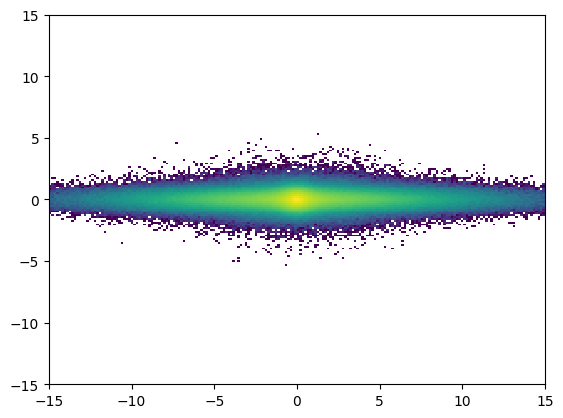

In [6]:
mass_unique = numpy.unique(mass, return_counts=True)
mask = mass==mass_unique[0][1]

plt.hist2d(pos[:,0], pos[:,2], bins=200, range=[[-15,15],[-15,15]], norm='log')

In [37]:
1.3e9 * 2.5**2 * 2*numpy.pi / 1e10

5.105088062083413

In [21]:
a= map(float, "1.1,1.2".split(','))
any(numpy.isclose(1.3, [1.1, 1.2]))

False

In [14]:
snap.nextFrame("")
snap.getValueF("time")

[True, 0.03125]